# Carga de conjunto de datos

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder
from utils import crear_conjuntos_con_validacion_estandarizados, get_device, mostrar_resumen_validacion

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Dividimos nuestro conjuntos de datos y lo estandarizamos respecto a la división de entrenamiento. original: B = 357, M = 212
conjuntos = crear_conjuntos_con_validacion_estandarizados(df, "diagnosis")
etiquetas = ["A", "B", "C"]

x_test, y_test, x_val, y_val, x_val_norm, y_val_norm, conjuntos_train = conjuntos 

device = get_device()

mostrar_resumen_validacion(conjuntos)

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

          conjunto  proporcion  normales  anomalías  total
0             test         NaN        72         42    114
1       validacion         NaN        71         43    114
2  validacion_norm         NaN        71          0     71
3            train        0.00       214          0    214
4            train        0.10       193         21    214
5            train        0.25       161         53    214


,conjunto,proporcion,normales,anomalías,total
0,test,NaN,72,42,114
1,validacion,NaN,71,43,114
2,validacion_norm,NaN,71,0,71
3,train,0.00,214,0,214
4,train,0.10,193,21,214
5,train,0.25,161,53,214


In [21]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder
from utils import get_device, crear_conjuntos_proporcionales_estandarizados, mostrar_resumen

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Dividimos nuestro conjuntos de datos y lo estandarizamos respecto a la división de entrenamiento, original: B = 357, M = 212
conjuntos = crear_conjuntos_proporcionales_estandarizados(df, "diagnosis", 0.2)

device = get_device()

# Desempaquetamos los conjuntos A, B y C
x_train_A, x_test_A, y_train_A, y_test_A = conjuntos[0]  # 0% de anómalos
x_train_B, x_test_B, y_train_B, y_test_B = conjuntos[1]  # 10% de anómalos
x_train_C, x_test_C, y_train_C, y_test_C = conjuntos[2]  # 25% de anómalos
print(x_train_A.shape)

# Es el mismo conjunto de prueba para todos
X = x_test_A
Y = y_test_A

mostrar_resumen(conjuntos)

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

(285, 30)
   Proporción  Positivos  Negativos  Total  % Positivos  % Negativos
0        0.00          0        285    285         0.00       100.00
1        0.10         28        257    285         9.82        90.18
2        0.25         71        214    285        24.91        75.09


In [22]:
# Modelos Autoencoder
modelo_A = Autoencoder.load(path="../models/Autoencoder_2025-12-06T21.06_lr=0.0001_set=A.pth", device=device)
modelo_B = Autoencoder.load(path="../models/Autoencoder_2025-12-06T21.08_lr=0.0001_set=B.pth", device=device)
modelo_C = Autoencoder.load(path="../models/Autoencoder_2025-12-06T21.09_lr=0.0001_set=C.pth", device=device)

modelo_A.summary()

<Autoencoder: In 30 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:163: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


In [23]:
# Modelos SAE
#modelo_A = Autoencoder.load(path="../models/SAE_2025-12-06T21.17_lr=0.0001_set=A.pth", device=device)
#modelo_B = Autoencoder.load(path="../models/SAE_2025-12-06T21.19_lr=0.0001_set=B.pth", device=device)
#modelo_C = Autoencoder.load(path="../models/SAE_2025-12-06T21.21_lr=0.0001_set=C.pth", device=device)

#modelo_A.summary()

In [24]:
# Modelos CAE
#modelo_A = Autoencoder.load(path="../models/CAE_2025-12-06T21.23_lr=0.01_set=A.pth", device=device)
#modelo_B = Autoencoder.load(path="../models/CAE_2025-12-06T21.25_lr=0.01_set=B.pth", device=device)
#modelo_C = Autoencoder.load(path="../models/CAE_2025-12-06T21.27_lr=0.01_set=C.pth", device=device)

#modelo_A.summary()

# Histograma de errores de reconstrucción

Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$

El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


In [25]:
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T20.28_lr=0.01_set=0.pth", device=device) # buen modelo
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T23.50_lr=0.001_set=0.pth", device=device) # bueno también
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-04T00.06_lr=0.001_set=0.pth", device=device) # buen modelo

In [26]:
#modelo_A = Autoencoder.load(path="../models/autoencoder_2025-12-05T20.59_lr=0.001_set=A.pth", device=device)
#modelo_B = Autoencoder.load(path="../models/autoencoder_2025-12-05T21.02_lr=0.001_set=B.pth", device=device)
#modelo_C = Autoencoder.load(path="../models/autoencoder_2025-12-05T21.05_lr=0.001_set=C.pth", device=device)

3.683
4.34
5.071
[A] normales=72, anomalías=42, normales > epsilon=8


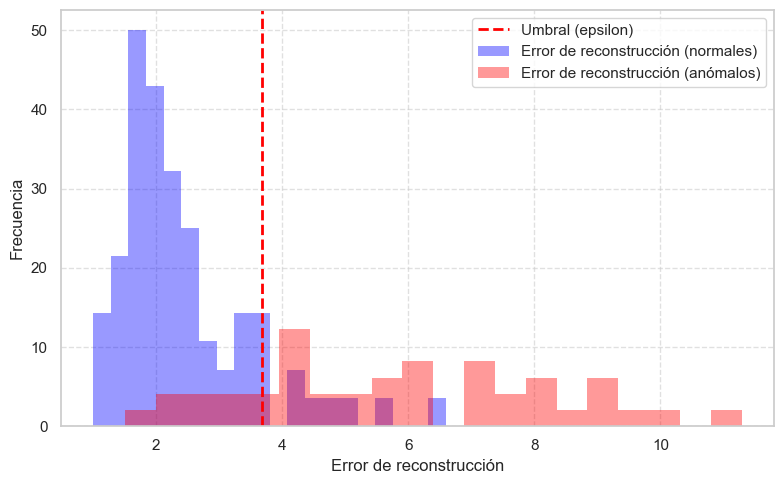

[B] normales=72, anomalías=42, normales > epsilon=11


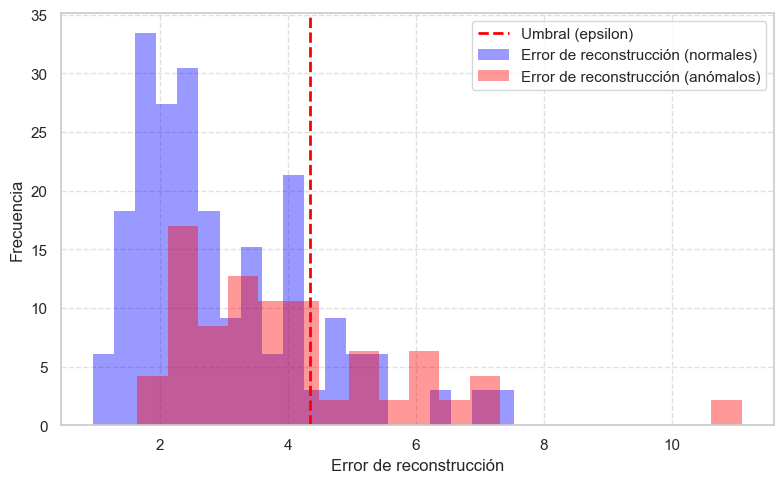

[C] normales=72, anomalías=42, normales > epsilon=7


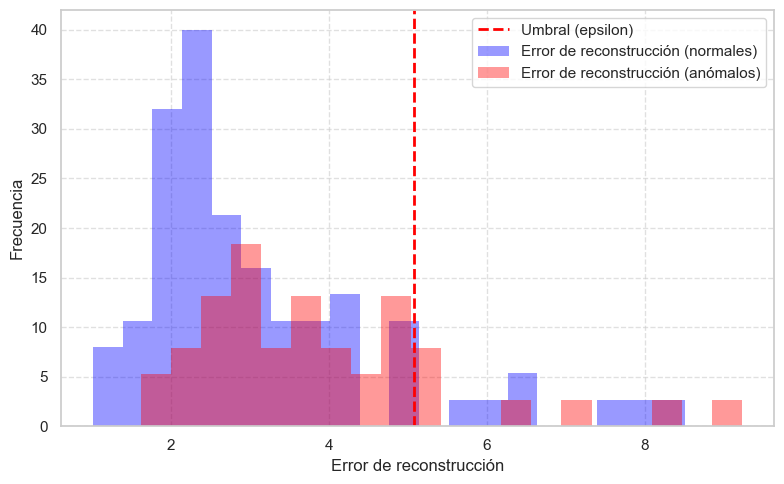

In [27]:
from utils import (evaluar_reconstruccion, obtener_epsilon,graficar_histograma_errores_reconstruccion,
                   obtener_matriz_confusion, obtener_metricas, graficar_matriz_confusion)
modelos = [modelo_A, modelo_B, modelo_C]
x_trains = [x_train_A, x_train_B, x_train_C]
nombres = ["A", "B", "C"]

dif_norm = []
dif_anom = []
epsilons = []

TIPO_NORMA = "L2" #"L1" "L2" "Linf" "MSE"
TIPO_EPSILON = 2

for modelo in modelos:
    _, dnorm = evaluar_reconstruccion(modelo, X[Y==0], device, tipo_norma=TIPO_NORMA)
    _, danom = evaluar_reconstruccion(modelo, X[Y==1], device, tipo_norma=TIPO_NORMA)
    dif_norm.append(dnorm)
    dif_anom.append(danom)
for modelo, xtrain in zip(modelos, x_trains):
    eps = obtener_epsilon(modelo, xtrain, device, tipo_epsilon=TIPO_EPSILON, tipo_norma=TIPO_NORMA)
    epsilons.append(eps)
for e in epsilons:
    print(round(e, 3))
for nombre, dnorm, danom, eps in zip(nombres, dif_norm, dif_anom, epsilons):
    print(f"[{nombre}] normales={len(X[Y==0])}, anomalías={len(X[Y==1])}, normales > epsilon={np.sum(dnorm > eps)}")
    graficar_histograma_errores_reconstruccion(dnorm, danom, epsilon=eps, kde=False, bins=20, stat="frequency")

# Matriz de confusión y métricas

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$

[A] Matriz: TP=35, FN=7, TN=64, FP=8
{'accuracy': 0.8684, 'precision': 0.814, 'recall': 0.8333, 'specificity': 0.8889, 'balanced_accuracy': 0.8611, 'f1_score': 0.8235}


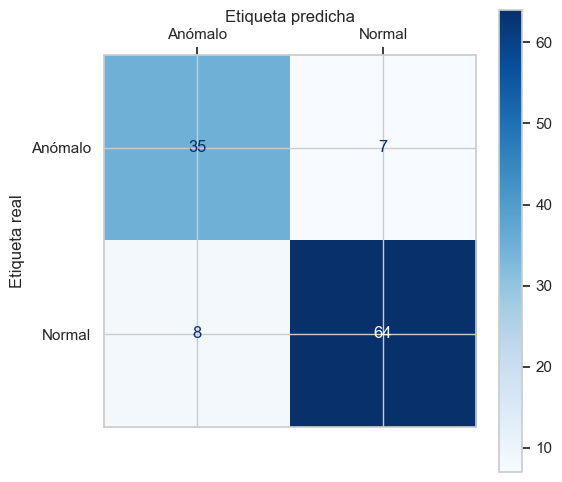

[B] Matriz: TP=15, FN=27, TN=61, FP=11
{'accuracy': 0.6667, 'precision': 0.5769, 'recall': 0.3571, 'specificity': 0.8472, 'balanced_accuracy': 0.6022, 'f1_score': 0.4412}


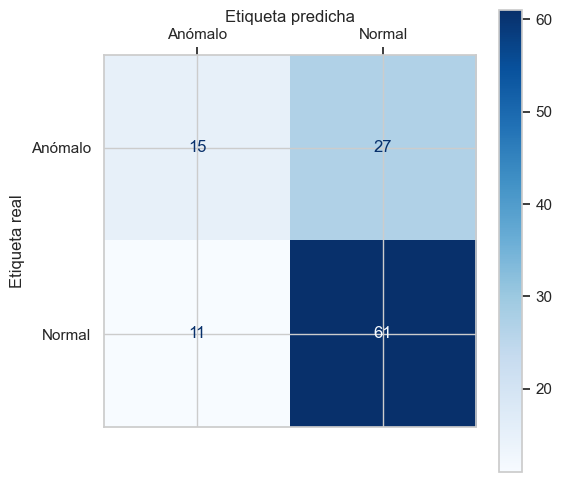

[C] Matriz: TP=6, FN=36, TN=65, FP=7
{'accuracy': 0.6228, 'precision': 0.4615, 'recall': 0.1429, 'specificity': 0.9028, 'balanced_accuracy': 0.5228, 'f1_score': 0.2182}


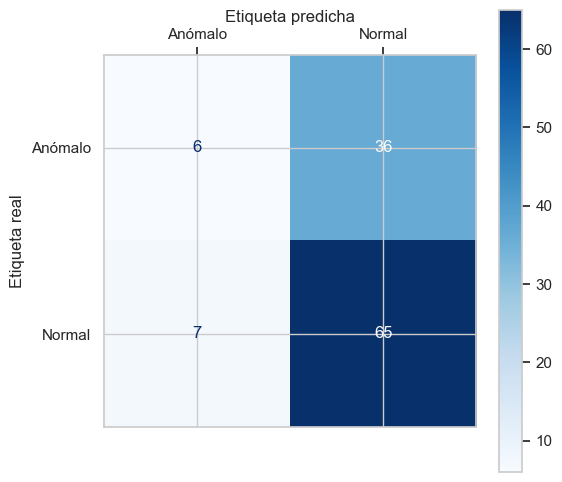

In [28]:
for nombre, dnorm, danom, eps in zip(nombres, dif_norm, dif_anom, epsilons):
    TP, FN, TN, FP = obtener_matriz_confusion(dnorm, danom, eps)
    print(f"[{nombre}] Matriz: TP={TP}, FN={FN}, TN={TN}, FP={FP}")
    print(obtener_metricas(TP, FN, TN, FP))
    graficar_matriz_confusion(TP, FN, TN, FP)

# Espacio latente

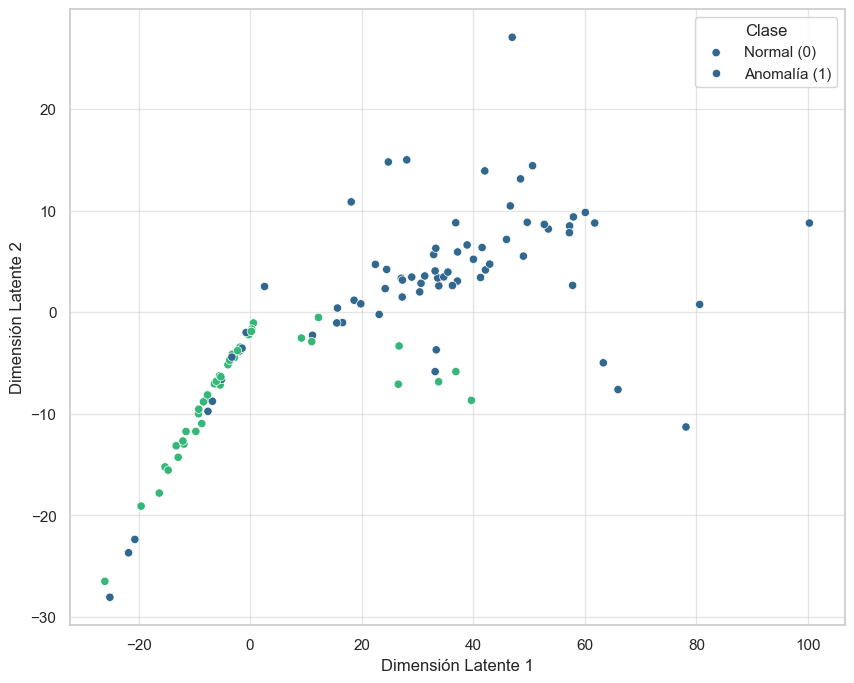

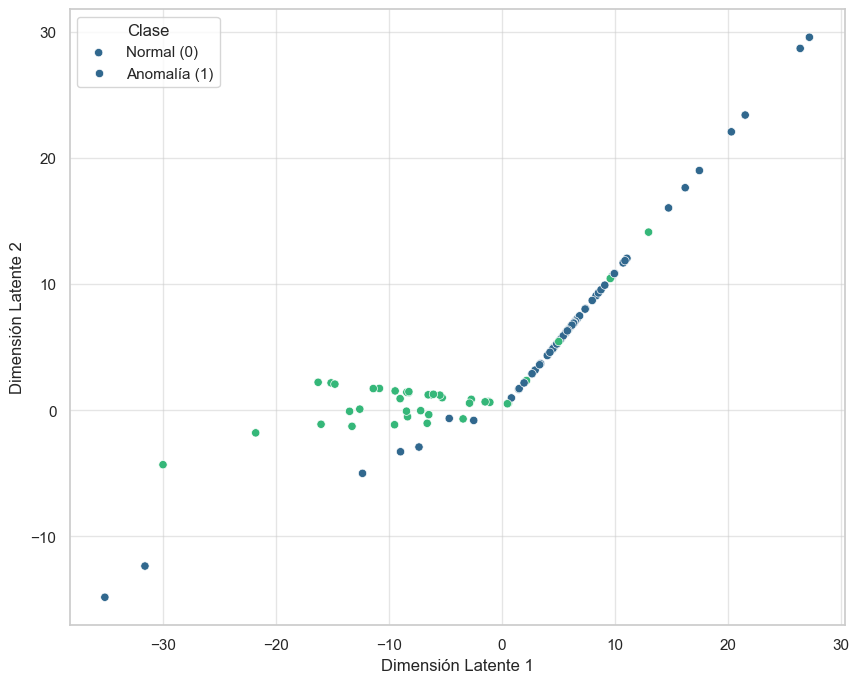

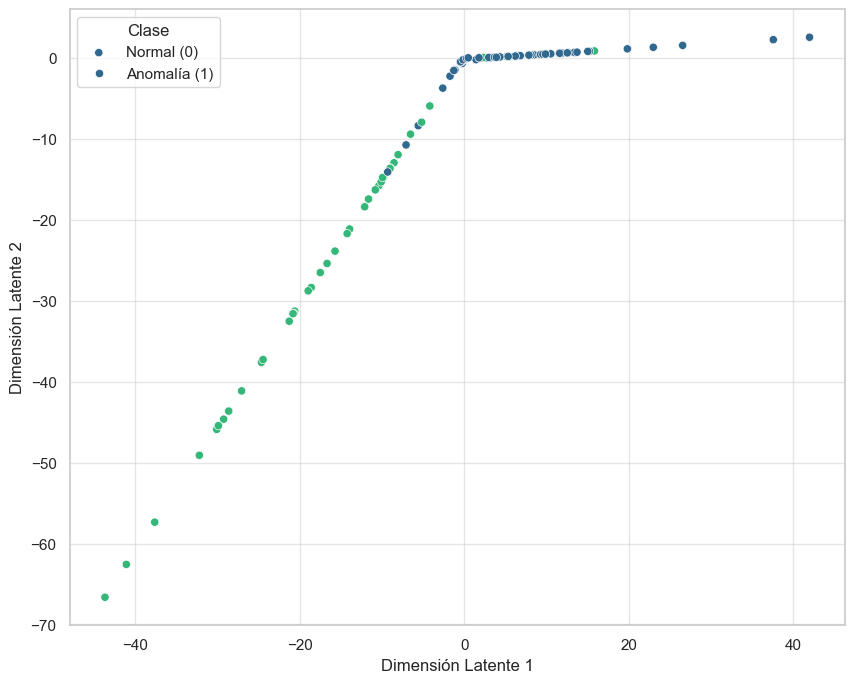

In [29]:
from utils import graficar_espacio_latente

z_A = modelo_A.encode(X, device)

graficar_espacio_latente(z_A, Y, ["Normal (0)", "Anomalía (1)"])

z_B = modelo_B.encode(X, device)

graficar_espacio_latente(z_B, Y, ["Normal (0)", "Anomalía (1)"])

z_C = modelo_C.encode(X, device)

graficar_espacio_latente(z_C, Y, ["Normal (0)", "Anomalía (1)"])

# Curva ROC y AUC

Hacer una curva ROC para cada conjunto (A, B y C)

Tamaño de conjunto de test: 114


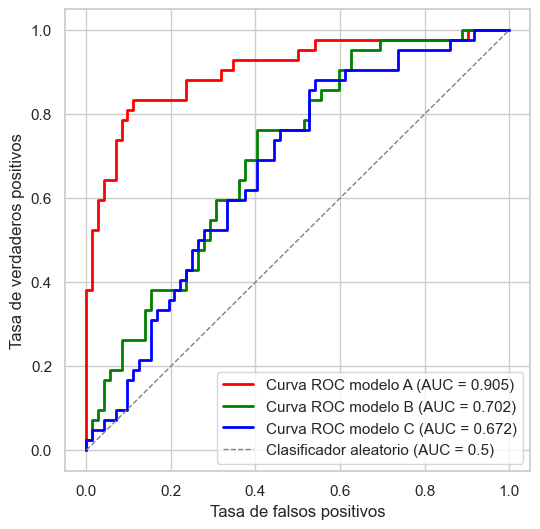

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print(f"Tamaño de conjunto de test: {len(X)}")

_, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, thresholds = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, thresholds = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, thresholds = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6,6))

plt.plot(fpr_A, tpr_A, color='red', lw=2, label=f'Curva ROC modelo A (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='green', lw=2, label=f'Curva ROC modelo B (AUC = {roc_auc_B:.3f})')
plt.plot(fpr_C, tpr_C, color='blue', lw=2, label=f'Curva ROC modelo C (AUC = {roc_auc_C:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05 ,1.05])
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score

scores = np.concatenate([dif_norm[1], dif_anom[1]])
labels = np.concatenate([np.zeros(len(dif_norm[1])), np.ones(len(dif_anom[1]))])

auc = roc_auc_score(labels, scores)
print(f"{auc:.3f}")

0.702


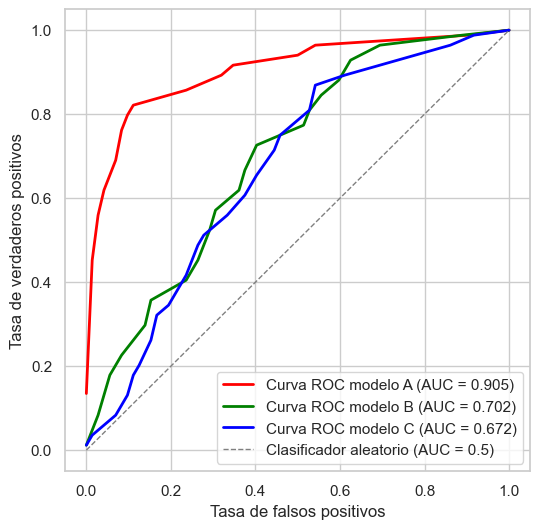

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid")

_, errores_A = evaluar_reconstruccion(modelo_A, X, device)
_, errores_B = evaluar_reconstruccion(modelo_B, X, device)
_, errores_C = evaluar_reconstruccion(modelo_C, X, device)

fpr_A, tpr_A, thresholds = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, thresholds = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, thresholds = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6,6))

sns.lineplot(x=fpr_A, y=tpr_A, color='red', lw=2, label=f'Curva ROC modelo A (AUC = {roc_auc_A:.3f})', errorbar=None)
sns.lineplot(x=fpr_B, y=tpr_B, color='green', lw=2, label=f'Curva ROC modelo B (AUC = {roc_auc_B:.3f})', errorbar=None)
sns.lineplot(x=fpr_C, y=tpr_C, color='blue', lw=2, label=f'Curva ROC modelo C (AUC = {roc_auc_C:.3f})', errorbar=None)

sns.lineplot(x=[0, 1], y=[0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.5)', errorbar=None)

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05 ,1.05])
plt.show()
